# Channel Estimate (Frame-wise CIR/CFR)

Compute and visualize CIR/CFR for selected frames.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sionna.rt import load_scene

from utils import (
    get_object_vertices,
    prepare_path_data,
    make_fixed_path_data,
    setup_tx_rx,
    get_cir_for_frame,
    get_cfr_for_frame,
)

np.set_printoptions(precision=3, suppress=True)


In [3]:
# 1) Config (single Tx/Rx default)
XML_PATH = Path('/data/hw/sionna/workspace/scenes/etri_0226/etri_260226_fixed.xml')
MERGE_SHAPES = False
RX_OBJECT_ID = 'car'   # used when RX_FIXED=False
TX_OBJECT_ID = 'car'   # used when TX_FIXED=False

RX_PATH_INDICES = [1, 14, 0, 12, 10, 8, 5, 4]
TX_PATH_INDICES = [0, 0]

RX_Z_OFFSET = 1.5
RX_SPEED_MS = 100.0 / 3.6
TX_Z_OFFSET = 20.0
TX_SPEED_MS = 0.0
DELTA_T = 0.2

RX_FIXED = False
RX_FIXED_POS = [80.0, -10.0, 1.5]
TX_FIXED = True
TX_FIXED_POS = [100.0, 20.0, 30.0]

RX_NAMES = ['rx1']
TX_NAMES = ['tx1']
TX_POWER_DBM = 43.0

SOLVER_KWARGS = dict(
    max_depth=3,
    samples_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
)

# CFR axis config
CENTER_FREQ_HZ = 3.5e9
BANDWIDTH_HZ = 20e6
NUM_FREQ = 256


In [5]:
# 2) Load scene and build path_data
scene = load_scene(str(XML_PATH), merge_shapes=MERGE_SHAPES)

if RX_FIXED:
    rx_path_data = make_fixed_path_data(RX_FIXED_POS, delta_t=DELTA_T)
else:
    rx_positions = get_object_vertices(scene, RX_OBJECT_ID, round_decimals=3)
    rx_idx = np.asarray(RX_PATH_INDICES, dtype=np.int32)
    if np.any(rx_idx < 0) or np.any(rx_idx >= len(rx_positions)):
        raise ValueError('RX_PATH_INDICES out of range')
    rx_path_data = prepare_path_data(rx_positions, rx_idx, z_offset=RX_Z_OFFSET, speed_ms=RX_SPEED_MS, delta_t=DELTA_T)

if TX_FIXED:
    tx_path_data = make_fixed_path_data(TX_FIXED_POS, delta_t=DELTA_T)
else:
    tx_positions = get_object_vertices(scene, TX_OBJECT_ID, round_decimals=3)
    tx_idx = np.asarray(TX_PATH_INDICES, dtype=np.int32)
    if np.any(tx_idx < 0) or np.any(tx_idx >= len(tx_positions)):
        raise ValueError('TX_PATH_INDICES out of range')
    tx_path_data = prepare_path_data(tx_positions, tx_idx, z_offset=TX_Z_OFFSET, speed_ms=TX_SPEED_MS, delta_t=DELTA_T)

tx_start_positions = [tx_path_data['waypoints'][0].tolist()]
rx_start_positions = [rx_path_data['waypoints'][0].tolist()]
tx_names, rx_names, solver = setup_tx_rx(
    scene=scene,
    tx_positions=tx_start_positions,
    rx_positions=rx_start_positions,
    tx_names=TX_NAMES,
    rx_names=RX_NAMES,
    tx_power_dbm=TX_POWER_DBM,
)
print('scene loaded:', XML_PATH.resolve())
print('tx_names=', tx_names, '| rx_names=', rx_names)
print('rx frames=', len(rx_path_data['frame_times']), '| tx frames=', len(tx_path_data['frame_times']))


scene loaded: /data/hw/sionna/workspace/scenes/etri_0226/etri_260226_fixed.xml
tx_names= ['tx1'] | rx_names= ['rx1']
rx frames= 44 | tx frames= 1


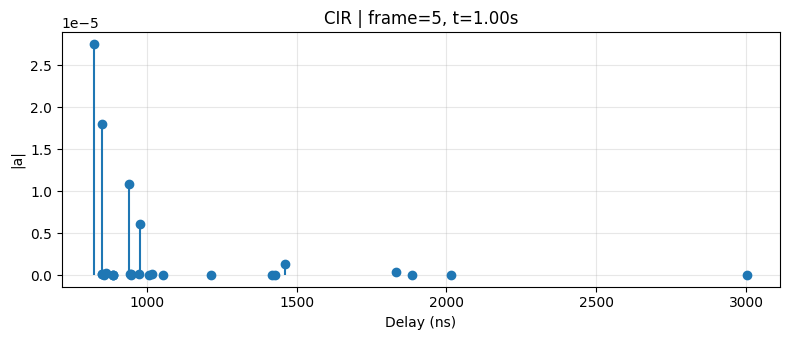

rx_pos= [ -77.927 -149.562    1.8  ] tx_pos= [100.  20.  30.]


In [7]:
# 3) CIR for one frame
def plot_cir_frame(frame_idx):
    result = get_cir_for_frame(
        scene=scene,
        solver=solver,
        rx_names=rx_names,
        rx_path_data=rx_path_data,
        tx_names=tx_names,
        tx_path_data=tx_path_data,
        frame_idx=int(frame_idx),
        cir_kwargs={},
        solver_kwargs=SOLVER_KWARGS,
        rx_idx=0,
    )
    tau_ns = result["tau_ns"]
    a_abs = result["a_abs"]
    t_s = result["time_s"]

    plt.figure(figsize=(8, 3.5))
    plt.stem(tau_ns, a_abs, basefmt=" ")
    plt.xlabel("Delay (ns)")
    plt.ylabel("|a|")
    plt.title(f"CIR | frame={frame_idx}, t={t_s:.2f}s")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("rx_pos=", result["rx_pos"][0], "tx_pos=", result["tx_pos"][0])
    return result

FRAME_IDX = 5
cir_result = plot_cir_frame(FRAME_IDX)


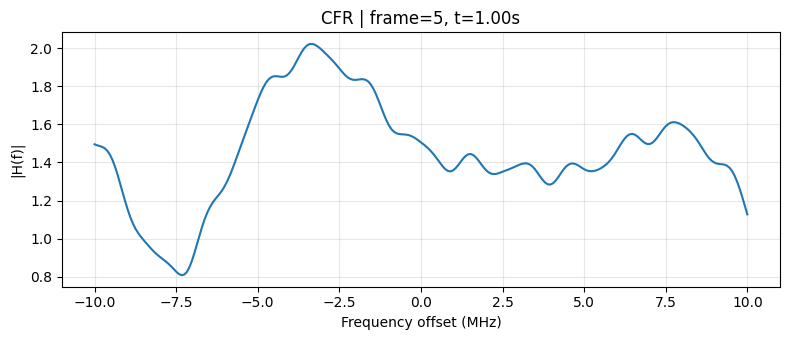

rx_pos= [ -77.927 -149.562    1.8  ] tx_pos= [100.  20.  30.]


In [9]:
# 4) CFR for one frame
frequencies = np.linspace(
    CENTER_FREQ_HZ - BANDWIDTH_HZ / 2,
    CENTER_FREQ_HZ + BANDWIDTH_HZ / 2,
    NUM_FREQ,
    dtype=np.float32,
)

def plot_cfr_frame(frame_idx):
    result = get_cfr_for_frame(
        scene=scene,
        solver=solver,
        rx_names=rx_names,
        rx_path_data=rx_path_data,
        tx_names=tx_names,
        tx_path_data=tx_path_data,
        frame_idx=int(frame_idx),
        frequencies=frequencies,
        cfr_kwargs=dict(normalize=True, normalize_delays=True),
        solver_kwargs=SOLVER_KWARGS,
        rx_idx=0,
    )

    h_abs = result["h_abs"]
    f_mhz = (frequencies - CENTER_FREQ_HZ) / 1e6
    t_s = result["time_s"]

    plt.figure(figsize=(8, 3.5))
    plt.plot(f_mhz, h_abs)
    plt.xlabel("Frequency offset (MHz)")
    plt.ylabel("|H(f)|")
    plt.title(f"CFR | frame={frame_idx}, t={t_s:.2f}s")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("rx_pos=", result["rx_pos"][0], "tx_pos=", result["tx_pos"][0])
    return result

FRAME_IDX = 5
cfr_result = plot_cfr_frame(FRAME_IDX)



===== frame 0 =====


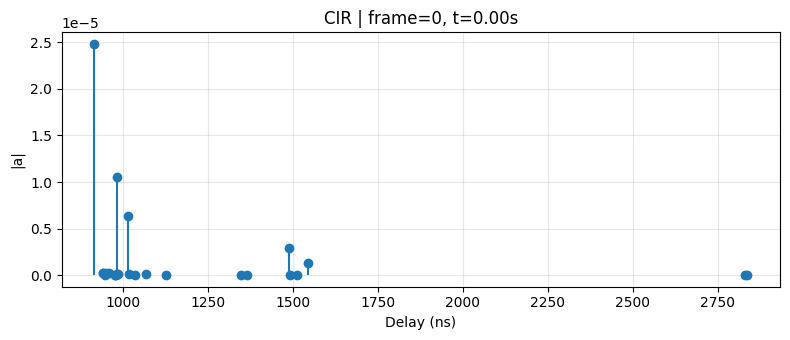

rx_pos= [ -97.653 -168.273    1.8  ] tx_pos= [100.  20.  30.]


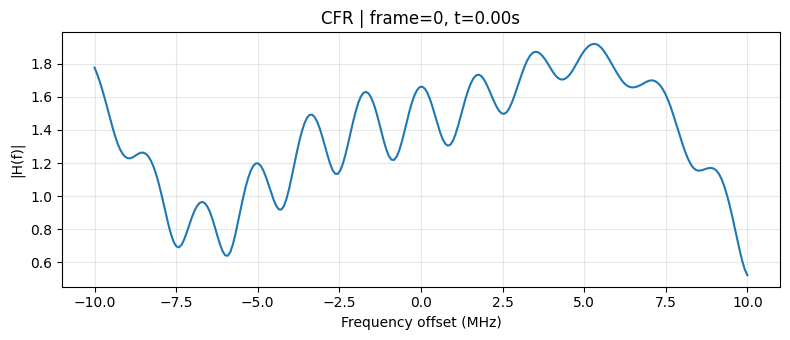

rx_pos= [ -97.653 -168.273    1.8  ] tx_pos= [100.  20.  30.]

===== frame 22 =====


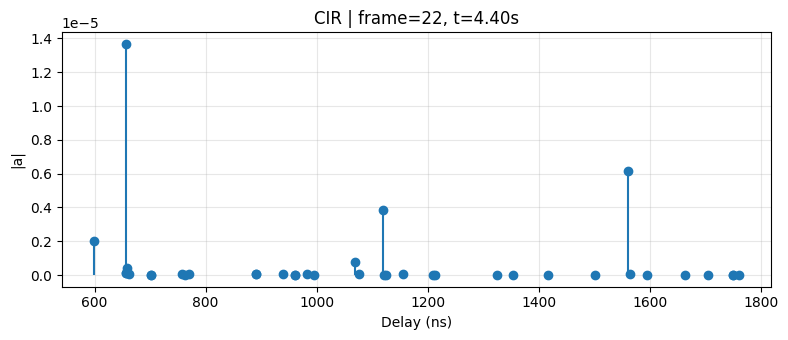

rx_pos= [-59.534 -57.484   1.8  ] tx_pos= [100.  20.  30.]


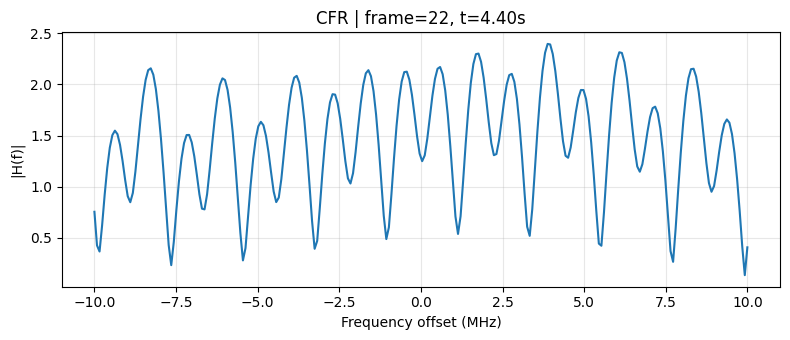

rx_pos= [-59.534 -57.484   1.8  ] tx_pos= [100.  20.  30.]

===== frame 43 =====


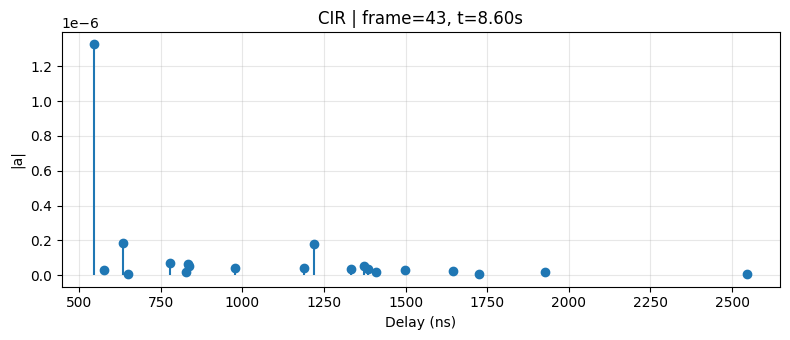

rx_pos= [-57.508  55.699   1.8  ] tx_pos= [100.  20.  30.]


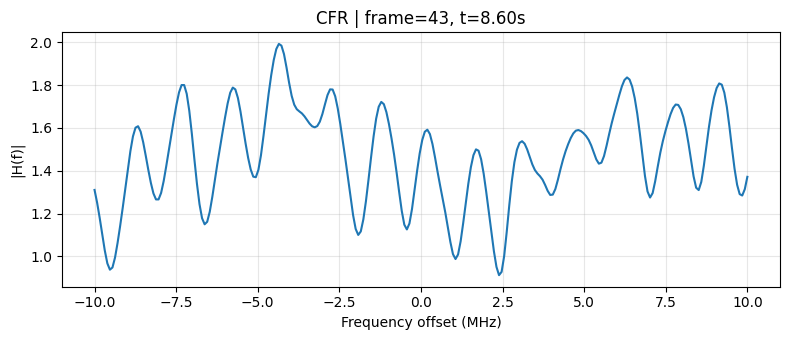

rx_pos= [-57.508  55.699   1.8  ] tx_pos= [100.  20.  30.]


In [10]:
# 5) Sweep selected frames (CIR + CFR)
num_frames = len(rx_path_data["frame_times"])
frame_list = [0, num_frames // 2, num_frames - 1]
frame_list = sorted(set(int(f) for f in frame_list if 0 <= f < num_frames))

for f in frame_list:
    print(f"\n===== frame {f} =====")
    _ = plot_cir_frame(f)
    _ = plot_cfr_frame(f)
